# 당뇨병 여부 분류
1. 데이터 로드
2. train / valid / test 데이터 분리
3. 결측치 처리 및 정규화
4. Tensor 변환
5. 미니배치 학습 준비
6. 다층 퍼셉트론 모델 준비
7. Optimizer / Scheduler / EarlyStopping 적용하여 학습
8. 학습 시각화
9. 각종 지표 확인
10. Optimizer 여러개 성능 비교
11. K-Fold Cross Validation

데이터셋 https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset



In [9]:
%pip install tqdm # 커널 가상환경에 바로 설치

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [10]:
import os                       # 운영체제 관련 제어
import random                   # 랜덤 시드 고정
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

import torch 
import torch.nn as nn           # 신경망 구성 및 손실함수
from torch.utils.data import TensorDataset, DataLoader # Tensor 데이터셋 / 미니배치 로더

import kagglehub                # 캐글 데이터셋 다운로드용
from tqdm.auto import tqdm      # 프로그래스바

from sklearn.model_selection import train_test_split, StratifiedKFold # 데이터 분리 / K-Fold 검증
from sklearn.pipeline import Pipeline                                 # 전처리 과정 통합
from sklearn.impute import SimpleImputer                              # 결측치 처리
from sklearn.preprocessing import StandardScaler                      # 표준화
from sklearn.metrics import ( 
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report
)


c:\Users\SJ\DL\dl_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [11]:
SEED = 42                             # 랜덤 시드값
 
random.seed(SEED)                     # 파이썬 랜덤 시드 고정
np.random.seed(SEED)                  # numpy 랜덤 시드 고정
torch.manual_seed(SEED)               # Pytorch CPU 랜덤 시드 고정

if torch.cuda.is_available():         
    torch.cuda.manual_seed_all(SEED)  # Pytorch GPU 랜덤 시드 고정

# GPU 가용시 device = "cuda", 아니면 "cpu"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device                         

device(type='cpu')

1. 데이터 로드

In [12]:
data_path = kagglehub.dataset_download("jamaltariqcheema/pima-indians-diabetes-dataset", path = "diabetes.csv")

df = pd.read_csv(data_path)
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76.0,48,180.0,32.9,0.171,63,0
764,2,122,70.0,27,102.5,36.8,0.340,27,0
765,5,121,72.0,23,112.0,26.2,0.245,30,0
766,1,126,60.0,32,169.5,30.1,0.349,47,1


In [13]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

|컬럼명|설명|
|---|---|
|Pregnancies|임신횟수|
|Glucose|포도당수치|
|BloodPressure|혈압|
|SkinThickness|피부두께|
|Insulin|인슐린수치|
|BMI|체질량지수|
|DiabatesPedigreeFunction|당뇨병 가족력 지표|
|Age|나이|
|Outcome|당뇨병 여부|

,count,ratio
Outcome,,
0,500,0.651042
1,268,0.348958


c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 53440 (\N{HANGUL SYLLABLE TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44191 (\N{HANGUL SYLLABLE GES}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54252 (\N{HANGUL SYLLABLE PO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


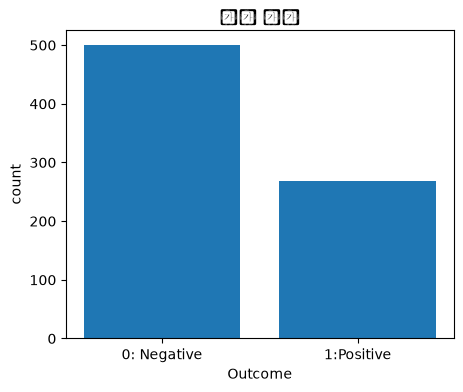

In [14]:
target_counts = df['Outcome'].value_counts().sort_index()
target_ratio = df['Outcome'].value_counts(normalize = True).sort_index()

display(pd.DataFrame({
    "count" : target_counts,
    "ratio" : target_ratio
}))

plt.figure(figsize = (5,4))
plt.bar(["0: Negative", "1:Positive"], target_counts.values)
plt.title("타겟 분포")
plt.xlabel("Outcome")
plt.ylabel("count")
plt.show()

2. train / valid / test 데이터 분리

In [15]:
X = df.drop(columns = 'Outcome')
y = df['Outcome']

print(X.shape, y.shape)

(768, 8) (768,)


In [16]:
# test데이터를 8:2 비율로 나눈다
X_train_valid, X_test, y_train_valid, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# 남은 80% 중 8:2 비율로 train / valid 데이터를 나눈다. (전역 시드값 설정, y_train_valid 비율 유지)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid, y_train_valid,
    test_size = 0.2,
    random_state = SEED,
    stratify = y_train_valid
)

print(f"X_train : {X_train.shape}, X_valid : {X_valid.shape}, X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}, y_valid : {y_valid.shape}, y_test : {y_test.shape}")

X_train : (491, 8), X_valid : (123, 8), X_test : (154, 8)
y_train : (491,), y_valid : (123,), y_test : (154,)


In [58]:
preprocess_pipeline = Pipeline([
    ("impiter", SimpleImputer(strategy = 'median')),
    ("scaler", StandardScaler())
])

X_train_scaled = preprocess_pipeline.fit_transform(X_train)
X_valid_scaled = preprocess_pipeline.transform(X_valid)
X_test_scaled =  preprocess_pipeline.fit_transform(X_test)

print(X_train_scaled.shape, X_valid_scaled.shape, X_test_scaled.shape)

(491, 8) (123, 8) (154, 8)


4. Tensor 형태로 변환

In [18]:
# 텐서 데이터로 변환 : y데이터는 모델 학습 및 사용에 적합하도록 2차원 형태로 변환
X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
X_valid_tensor = torch.FloatTensor(X_valid_scaled)
X_test_tensor =  torch.tensor(X_test_scaled, dtype = torch.float32)

y_train_tensor = torch.tensor(y_train.to_numpy(), dtype = torch.float32).reshape(-1,1)
y_valid_tensor = torch.tensor(y_valid.to_numpy(), dtype = torch.float32).reshape(-1,1)
y_test_tensor = torch.tensor(y_test.to_numpy(), dtype = torch.float32).reshape(-1,1)

print(f"X_train : {X_train.shape}, X_valid : {X_valid.shape}, X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}, y_valid : {y_valid.shape}, y_test : {y_test.shape}")

X_train : (491, 8), X_valid : (123, 8), X_test : (154, 8)
y_train : (491,), y_valid : (123,), y_test : (154,)


5. 미니배치 학습 준비

In [19]:
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# DataLoader를 사용해서 미니배치 단위로 데이터를 나눠 학습
train_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

# 검증 데이터셋과 테스트 데이터셋을 만들기

valid_loader = DataLoader(
    train_dataset,
    batch_size = BATCH_SIZE,
    shuffle = True
)

test_loader = DataLoader(
    valid_dataset,
    batch_size = BATCH_SIZE,
    shuffle = False
)

print(len(train_loader), len(valid_loader), len(test_loader))

16 16 4


6. 다층 퍼셉트론 모델 정의

In [20]:
class DiabetesMLP(nn.Module):
    def __init__(self, input_dim, hidden_dims = (64,32,16), dropout = 0.2, activation = "silu"):
        super().__init__()

        layers = []                                        # 신경망 계층을 모두 저장할 리스트
        prev_dim = input_dim                               # 이전 계층의 출력 차원

        for hidden_dim in hidden_dims:                     
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))      # 배치 정규화 (평균 0, 표준편차 1) : 수치 안정화 -> 학습 안정화

            # 활성화 함수 추가 (비선형성 추가)
            if activation == 'relu':
                layers.append(nn.Relu())
            elif activation == 'gelu':
                layers.appeend(nn.GELU())
            elif activation == 'silu':
                layers.append(nn.SiLU())
            else:
                raise ValueError("활성화함수는 relu, gelu, silu 중 하나로 선택해 주세요!")

            layers.append(nn.Dropout(dropout))  # 일부 파라미터 생략 (과적합 완화)
            prev_dim = hidden_dim               
 
        layers.append(nn.Dropout(dropout))      # 이진 분류 출력층
        prev_dim = hidden_dim                   # 계층들을 순서대로 연결

        layers.append(nn.Linear(prev_dim,1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)        

                        


In [21]:
input_dim = X_train_tensor.size(-1)                 # 입력 특성 개수

model = DiabetesMLP(input_dim = input_dim).to(device) 

model



DiabetesMLP(
  (net): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.2, inplace=False)
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=16, out_features=1, bias=True)
  )
)

In [22]:
# 양성 클래스 비율이 낮을 때 양성 클래스에 더 큰 가중치를 부여하는 손실함수
num_positive = y_train_tensor.sum()
num_negative = len(y_train_tensor) - num_positive
pos_weight = (num_negative / num_positive).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight = pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr = 0.001,
    weight_decay = 1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode = 'min',
    factor = 0.5,
    patience = 5
)

In [23]:
class EarlyStopping:
    def __init__(self, patience = 20, min_delta = 0.0):
        self.patience = patience                        # 개선이 없을때 기다릴 epoch 수
        self.min_delta = min_delta                      # 개선으로 인정할 최소 손실 감소량
        self.best_loss = np.inf
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, valid_loss, model):
        if valid_loss < self.best_loss - self.min_delta:
            self.best_loss = valid_loss
            self.counter = 0

            self.best_state = {
                key : value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }
        else:
            self.counter += 1

            if self.counter >= self.patience:
                self.should_stop = True

In [24]:
def train_one_epoch(model, data_loader, criterion, optimizer, device):
    model.train()          # 학습모드
    total_loss = 0         # 전체 손실

    # 미니배치 32개 단위로 반복
    for X_batch, y_batch in data_loader:
        X_batch = X_batch.to(device)     # 입력 데이터를 CPU/GPU로 이동
        y_batch = y_batch.to(device)     # 정답 데이터를 CPU/GPU로 이동

        optimizer.zero_grad()            # 이전 step 기울기 초기화
        logits = model(X_batch)          # 정답 데이터를 cpu/gpu로 이동
        loss = criterion(logits, y_batch)
     
        loss.backward()                  # 이전 step 기울기 초기화
        optimizer.step()                 # 예측값 계산

        total_loss += loss.item() * len(X_batch) # 배치 손실 계산

    return total_loss / len(data_loader.dataset) # 

def evaluate_loss(model, data_loader, criterion, device):
    model.eval()                   # 평가 모드로 설정
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in data_loader: 
            X_batch = X_batch.to(device) # 입력 데이터 장치로 이동    
            y_batch = y_batch.to(device) # 정답 데이터 장치로 이동

            logits = model(X_batch)# 예측값 계산
            loss = criterion(logits, y_batch)# 손실값 계산

            total_loss += loss.item() * len(X_batch) # 배치 손실을 데이터 수만큼 누적

        return total_loss / len(data_loader.dataset)     # 평균 손실 반환|

In [25]:

EPOCHS = 200  # 최대 학습 횟수


# 20번 동안 최소 개선 기준 0.0001 이상 개선되지 않으면 학습 중단
early_stopping = EarlyStopping(patience = 20, min_delta = 0.0001) 

history = []

for epoch in tqdm(range(EPOCHS), desc = 'Training'):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)

    valid_loss = evaluate_loss(model, valid_loader, criterion, device)

    scheduler.step(valid_loss)

    current_lr = optimizer.param_groups[0]["lr"]

    history.append({
        "epoch" : epoch + 1,
        "train_loss" : train_loss,
        "valid_loss" : valid_loss,
        "lr" : current_lr
    })

    early_stopping.step(valid_loss, model)

    if early_stopping.should_stop:
        print(f"{epoch + 1} Epoch에서 Early Stopping 작동하여 학습 중지!")
        break
if early_stopping.best_state is not None:
    model.load_state_dict(early_stopping.best_state)

history_df = pd.DataFrame(history)
history_df        


Training:   0%|          | 0/200 [00:00<?, ?it/s]

Training:  72%|███████▏  | 143/200 [00:08<00:03, 17.27it/s]

144 Epoch에서 Early Stopping 작동하여 학습 중지!


,epoch,train_loss,valid_loss,lr
0,1,0.865651,0.858056,0.001000
1,2,0.758600,0.744242,0.001000
2,3,0.720277,0.677326,0.001000
3,4,0.675794,0.637938,0.001000
4,5,0.641598,0.615522,0.001000
...,...,...,...,...
139,140,0.353869,0.333313,0.000063
140,141,0.300378,0.334064,0.000063
141,142,0.309012,0.331266,0.000031
142,143,0.297971,0.331915,0.000031


In [31]:
def predict_proba(model, data_loader, device):
    model.eval()              # 평가모드
    proba_list = []           # 예측 확률
    target_list = []          # 정답


    # 예측시 기울기 계산 비활성화
    with torch.no_grad():
        for X_batch, y_batch, in data_loader:
            X_batch = X_batch.to(device)

            logits = model(X_batch)
            proba = torch.sigmoid(logits)

            proba_list.append(proba.cpu().numpy())
            target_list.append(y_batch.numpy())

    y_proba = np.vstack(proba_list).ravel()       
    y_true = np.vstack(target_list).ravel()       

    return y_true, y_proba    


- validation 데이터로 threshold 확인하고 변경하여 지표 확인
    - 기본 임계값은 0.5
    - 모델의 목적에 따라 임계값을 조정해서 사용하기도 한다.
    - 예를 들어 양성 클래스를 더 잘 잡는 걸 목표로 한다면 precision이 좀 낮아지더라도 recall 수치를 우선적으로 높일 수 있다.

In [47]:
y_valid_true, y_valid_proba = predict_proba(model, valid_loader, device)

thresholds = np.arange(0.1, 0.91, 0.05)

threshold_result = []

for threshold in thresholds:
    y_valid_pred = (y_valid_proba >= threshold).astype(int)

    threshold_result.append({
        "threshold" : threshold,
        "accuracy" : accuracy_score(y_valid_true, y_valid_pred),
        "precision" : precision_score(y_valid_true, y_valid_pred, zero_division = 0),
        "recall" : recall_score(y_valid_true, y_valid_pred, zero_division = 0),
        "f1":f1_score(y_valid_true, y_valid_pred, zero_division = 0),
    })

threshold_df = pd.DataFrame(threshold_result)
threshold_df.sort_values("f1", ascending=False).head()    

,threshold,accuracy,precision,recall,f1
11,0.65,0.906314,0.887500,0.835294,0.860606
10,0.60,0.904277,0.877301,0.841176,0.858859
9,0.55,0.894094,0.835227,0.864706,0.849711
12,0.70,0.898167,0.894737,0.800000,0.844720
6,0.40,0.879837,0.773399,0.923529,0.841823


In [48]:
best_threshold = threshold_df.sort_values("f1", ascending = False).iloc[0]["threshold"]
best_threshold

np.float64(0.6500000000000001)

c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51076 (\N{HANGUL SYLLABLE IM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


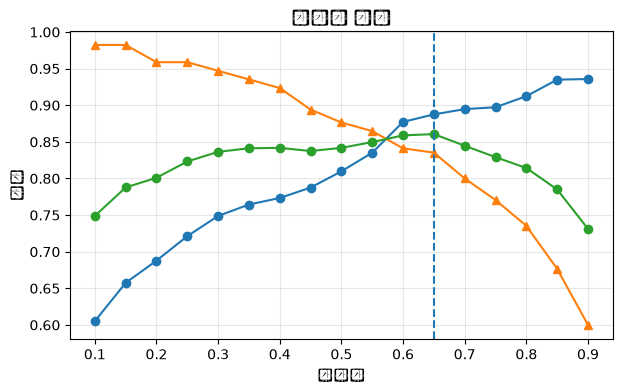

In [49]:
#임계값별 지표 시각화
plt.figure(figsize=(7,4))
plt.plot(threshold_df["threshold"],threshold_df["precision"], marker = "o", label = 'Precision')
plt.plot(threshold_df["threshold"],threshold_df["recall"], marker = "^", label = 'Recall')
plt.plot(threshold_df["threshold"],threshold_df["f1"], marker = "o", label = 'F1-Score')
plt.axvline(best_threshold, linestyle = '--', label=f"Best Threshold: {best_threshold:.2f}")

plt.title("임계값 비교")
plt.xlabel("임계값")
plt.ylabel("점수")
plt.grid(alpha = 0.3) # 격자
plt.show()

In [46]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [50]:
y_test_true, y_test_proba = predict_proba(model, test_loader, device)

y_test_pred = (y_test_proba >= best_threshold).astype(int)


test_metrics = {
        "accuracy" : threshold,
        "precision" : accuracy_score(y_test_true, y_test_pred),
        "precision" : precision_score(y_test_true, y_test_pred, zero_division = 0),
        "recall" : recall_score(y_test_true, y_test_pred, zero_division = 0),
        "f1":f1_score(y_test_true, y_test_pred, zero_division = 0),
        "roc_auc" : roc_auc_score(y_test_true, y_test_proba),
        "pr_auc" : average_precision_score(y_test_true, y_test_proba)
    }

pd.DataFrame([test_metrics])

,accuracy,precision,recall,f1,roc_auc,pr_auc
0,0.9,0.833333,0.813953,0.823529,0.957267,0.930729


In [52]:
print(classification_report(y_test_true,  # 실제값
                      y_test_pred,  # 예측값
                      target_names = ["Negative", "Positive"], # 클래스 이름
                      zero_division = 0  # 분모 0 나눌시 오류는 0 값으로 처리
                      ))

              precision    recall  f1-score   support

    Negative       0.90      0.91      0.91        80
    Positive       0.83      0.81      0.82        43

    accuracy                           0.88       123
   macro avg       0.87      0.86      0.87       123
weighted avg       0.88      0.88      0.88       123



c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw

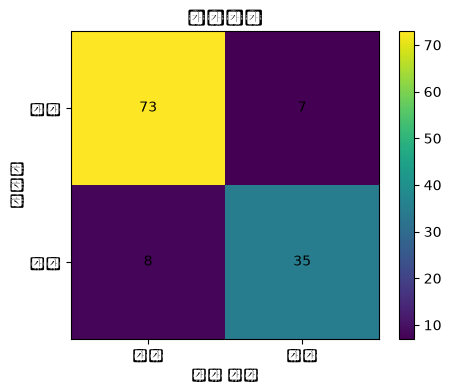

In [53]:
cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize = (5,4))
plt.imshow(cm)
plt.title("혼동행렬")
plt.xlabel("모델 예측")
plt.ylabel("실제값")
plt.xticks([0,1], ["음성","양성"])
plt.yticks([0,1], ["음성","양성"])
plt.colorbar()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha = 'center', va = 'center')

plt.show()        

c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51020 (\N{HANGUL SYLLABLE EUM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50577 (\N{HANGUL SYLLABLE YANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

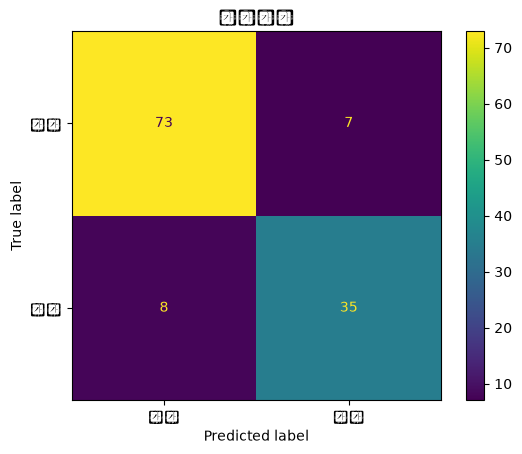

In [54]:
# ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test_true, y_test_pred) # 혼동 행렬 계산

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = ["음성", "양성"]
)

disp.plot()
plt.title("혼동행렬")
plt.show()

c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54869 (\N{HANGUL SYLLABLE HWAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\SJ\DL\dl_venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 47456 (\N{HANGUL SYLLABLE RYUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)

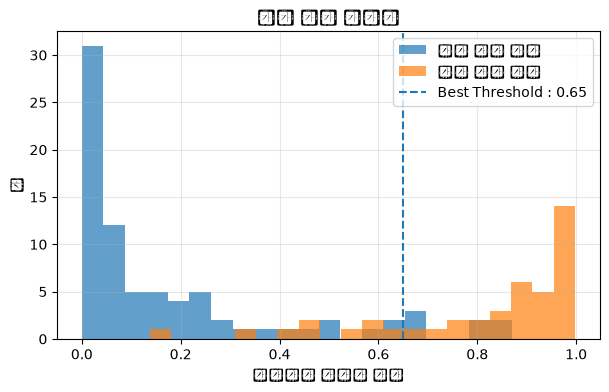

In [56]:
# 예측 확률 분포도
plt.figure(figsize = (7,4))
plt.hist(y_test_proba[y_test_true==0], bins = 20, alpha = 0.7, label = "실제 음성 예측")
plt.hist(y_test_proba[y_test_true == 1], bins = 20, alpha = 0.7, label = "실제 양성 예측")
plt.axvline(best_threshold, linestyle = '--', label=f"Best Threshold : {best_threshold:.2f}")
plt.title("예측 확률 분포도")
plt.xlabel("양성으로 예측한 확률")
plt.ylabel("수")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

In [61]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [66]:
# 샘플 데이터로 예측해보기
sample = pd.DataFrame([{
    'Pregnancies' : 6,
    'Glucose' : 200,
    'BloodPressure' : 60,
    'SkinThickness' : 25,
    'Insulin' : 90,
    'BMI' : 28.5,
    'DiabetesPedigreeFunction' : 0.45,
    'Age': 35
}])

sample_scaled = preprocess_pipeline.transform(sample)
sample_tensor = torch.FloatTensor(sample_scaled).to(device)

model.eval()
with torch.no_grad():
    logit = model(sample_tensor)
    proba  = torch.sigmoid(logit).item()
    pred = int(proba > best_threshold)

print(f"양성 클래스일 확률 : {proba:.4f}, 예측 클래스 : {pred}")    

양성 클래스일 확률 : 0.2918, 예측 클래스 : 0
